## Portfolio archive and evaluation note

This notebook is retained as part of the original MRI denoising experiment suite. Saved cells and outputs are included so the development work can be reviewed without rerunning long GPU training jobs.

> **Evaluation limitation:** In the supplied workflow, several experiments use the same image directory for both training and validation. The stored metrics are therefore historical development results, not independently reproduced estimates from a held-out validation set. A reliable rerun should use patient-level train, validation, and test splits.

The code was developed in Google Colab and contains hard-coded paths under `/content/drive/MyDrive/Final RI/`. Update those paths before running it with your own dataset.


In [ ]:
# ===========================
#  Cell 1: Rician-Only Noise with Logging
# ===========================
import os, cv2, numpy as np, glob, random, zipfile, pandas as pd
from tqdm import tqdm
from google.colab import drive

# --- 1. Mount Google Drive for data access ---
drive.mount('/content/drive')

# --- 2. Extract dataset if not already extracted ---
zip_path = "/content/drive/MyDrive/Final RI/glioma.zip"
extract_path = "/content/drive/MyDrive/Final RI/glioma"
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(" Extracted glioma.zip to:", extract_path)
else:
    print(" glioma/ already exists. Skipping extraction.")

# --- 3. Define clean and Rician-noisy image directories ---
CLEAN_DIR = extract_path
NOISY_DIR = "/content/drive/MyDrive/Final RI/single_noise_outputs/single_noise_outputs_rician"
os.makedirs(NOISY_DIR, exist_ok=True)

# --- 4. Set random seeds for reproducibility ---
random.seed(42)
np.random.seed(42)

# --- 5. Define Rician noise function ---
def safe_clip(img):
    return np.clip(img, 1e-6, 1.0)

def add_rician_noise(img, sigma=0.05):
    noise_real = np.random.normal(0, sigma, img.shape)
    noise_imag = np.random.normal(0, sigma, img.shape)
    return safe_clip(np.sqrt((img + noise_real)**2 + noise_imag**2))

# --- 6. Generate and save Rician-noised versions of all images ---
image_paths = sorted(glob.glob(os.path.join(CLEAN_DIR, "*.*")))
log_data = []

print(f" Found {len(image_paths)} clean images to process")

for img_path in tqdm(image_paths, desc=" Adding Rician noise to all images"):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f" Skipping unreadable file: {img_path}")
        continue

    img = cv2.resize(img, (256, 256)).astype(np.float32) / 255.0

    #  Apply Rician noise only
    img_noisy = add_rician_noise(img, sigma=0.05)
    noise_types = ["Rician"]

    out_path = os.path.join(NOISY_DIR, os.path.basename(img_path))
    img_save = (img_noisy * 255).astype(np.uint8)
    cv2.imwrite(out_path, img_save)

    log_data.append({
        "filename": os.path.basename(img_path),
        "noise_types": " + ".join(noise_types)
    })

# --- 7. Save noise log as CSV for reproducibility and analysis ---
log_df = pd.DataFrame(log_data)
csv_path = os.path.join(NOISY_DIR, "noise_log.csv")
log_df.to_csv(csv_path, index=False)

print(f" Rician-noised images saved to: {NOISY_DIR}")
print(f" Noise log saved to: {csv_path}")


Mounted at /content/drive
📂 glioma/ already exists. Skipping extraction.
🔍 Found 1297 clean images to process


🔧 Adding Rician noise to all images: 100%|██████████| 1297/1297 [08:14<00:00,  2.62it/s]


✅ Rician-noised images saved to: /content/drive/MyDrive/Final RI/single_noise_outputs/single_noise_outputs_rician
📄 Noise log saved to: /content/drive/MyDrive/Final RI/single_noise_outputs/single_noise_outputs_rician/noise_log.csv


In [ ]:
# ===========================
#  Cell 2: Dataset Loader for Rician-Only Denoising
# ===========================
import torch
from torch.utils.data import Dataset
from torchvision import transforms
import os, cv2, numpy as np
import glob

# --- Define preprocessing transformation: converts grayscale images to tensors ---
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts (H, W) to (1, H, W) float32 in [0, 1]
])

# --- Dataset class for paired MRI noisy-clean image loading ---
class MRIDenoisingDataset(Dataset):
    def __init__(self, noisy_dir, clean_dir, transform=None):
        # Collect all image file paths from noisy and clean directories
        noisy_all = sorted(glob.glob(os.path.join(noisy_dir, "*.*")))
        clean_all = sorted(glob.glob(os.path.join(clean_dir, "*.*")))

        # Filter and index image files by filename
        noisy_dict = {os.path.basename(p): p for p in noisy_all if p.lower().endswith(('.png', '.jpg', '.jpeg'))}
        clean_dict = {os.path.basename(p): p for p in clean_all if p.lower().endswith(('.png', '.jpg', '.jpeg'))}

        # Find common image filenames present in both directories
        common_filenames = sorted(set(noisy_dict.keys()) & set(clean_dict.keys()))
        assert common_filenames, " No matching image files found between noisy and clean dirs."

        # Store matched paths
        self.noisy_paths = [noisy_dict[f] for f in common_filenames]
        self.clean_paths = [clean_dict[f] for f in common_filenames]
        self.transform = transform

        print(f"[INFO]  Matched {len(self.noisy_paths)} image pairs.")

    def __len__(self):
        return len(self.noisy_paths)

    def __getitem__(self, idx):
        noisy_path = self.noisy_paths[idx]
        clean_path = self.clean_paths[idx]

        # Load images in grayscale
        noisy = cv2.imread(noisy_path, cv2.IMREAD_GRAYSCALE)
        clean = cv2.imread(clean_path, cv2.IMREAD_GRAYSCALE)

        if noisy is None or clean is None:
            raise ValueError(f"Invalid image: {noisy_path} or {clean_path}")

        # Resize to 256x256 and normalize to [0, 1]
        noisy = cv2.resize(noisy, (256, 256)).astype(np.float32) / 255.0
        clean = cv2.resize(clean, (256, 256)).astype(np.float32) / 255.0

        # Apply defined transform (e.g., ToTensor)
        if self.transform:
            noisy = self.transform(noisy)
            clean = self.transform(clean)

        return noisy, clean

# --- Define training and validation directory paths (Rician-only) ---
train_noisy_dir = "/content/drive/MyDrive/Final RI/single_noise_outputs/single_noise_outputs_rician"
val_noisy_dir   = "/content/drive/MyDrive/Final RI/single_noise_outputs/single_noise_outputs_rician"
train_clean_dir = "/content/drive/MyDrive/Final RI/glioma"
val_clean_dir   = "/content/drive/MyDrive/Final RI/glioma"

# --- Create dataset objects for training and validation ---
train_dataset = MRIDenoisingDataset(train_noisy_dir, train_clean_dir, transform)
val_dataset   = MRIDenoisingDataset(val_noisy_dir, val_clean_dir, transform)

print(f"[INFO]  Loaded {len(train_dataset)} training images")
print(f"[INFO]  Loaded {len(val_dataset)} validation images")


[INFO] ✅ Matched 1297 image pairs.
[INFO] ✅ Matched 1297 image pairs.
[INFO] ✅ Loaded 1297 training images
[INFO] ✅ Loaded 1297 validation images


In [ ]:
# ===========================
#  Cell 3: Generator – VAE-integrated U-Net Architecture
#  Patched with full NaN-safe latent + output handling
# ===========================
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- Convolutional block with Instance Normalization and LeakyReLU activation ---
def conv_block(in_channels, out_channels, kernel_size=3, stride=1, padding=1):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
        nn.InstanceNorm2d(out_channels),
        nn.LeakyReLU(0.2, inplace=True)
    )

# --- VAE + U-Net based Generator ---
class UNetGenerator(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, latent_dim=256):
        super(UNetGenerator, self).__init__()

        # --- Encoder ---
        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)
        self.pool = nn.MaxPool2d(2)

        # --- Bottleneck ---
        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(512 * 16 * 16, latent_dim)
        self.fc_logvar = nn.Linear(512 * 16 * 16, latent_dim)
        self.fc_decoder = nn.Linear(latent_dim, 512 * 16 * 16)
        self.unflatten = nn.Unflatten(1, (512, 16, 16))

        # --- Decoder ---
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec1 = conv_block(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(256, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec3 = conv_block(128, 64)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # --- Encoder ---
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        e4_pool = self.pool(e4)

        # --- Latent space ---
        flat = self.flatten(e4_pool)
        mu = self.fc_mu(flat)
        logvar = self.fc_logvar(flat)

        #  NaN and overflow protection
        mu = torch.nan_to_num(mu, nan=0.0)
        logvar = torch.nan_to_num(logvar, nan=0.0)
        logvar = torch.clamp(logvar, min=-20.0, max=20.0)

        z = self.reparameterize(mu, logvar)
        z = self.unflatten(self.fc_decoder(z))
        z = F.interpolate(z, size=(32, 32), mode='bilinear', align_corners=False)

        # --- Decoder ---
        d1 = self.up1(z)
        d1 = self.dec1(torch.cat([d1, e3], dim=1))

        d2 = self.up2(d1)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d3 = self.up3(d2)
        d3 = self.dec3(torch.cat([d3, e1], dim=1))

        out = torch.sigmoid(self.out_conv(d3))

        #  Protect against NaNs in output
        if torch.isnan(out).any():
            print(" Generator output contains NaN – replacing with zeros")
            out = torch.zeros_like(out)

        return out, mu, logvar


In [ ]:
# ===========================
#  Cell 4: DWT + PatchGAN Discriminator
# ===========================
import torch
import torch.nn as nn
import torch.nn.functional as F
import pywt
import numpy as np

# --- Discrete Wavelet Transform (DWT) Layer: Extracts LL, LH, HL, HH components per channel ---
class DWT_2D(nn.Module):
    def __init__(self, wave='haar'):
        super(DWT_2D, self).__init__()
        self.wave = wave

    def forward(self, x):
        B, C, H, W = x.shape
        dwt_output = []
        for b in range(B):
            channels = []
            for c in range(C):
                arr = x[b, c].detach().cpu().numpy()
                LL, (LH, HL, HH) = pywt.dwt2(arr, self.wave)
                channels.extend([LL, LH, HL, HH])
            stacked = np.stack(channels)
            dwt_output.append(torch.from_numpy(stacked).float())
        return torch.stack(dwt_output).to(x.device)

# --- PatchGAN-style Discriminator that operates on DWT frequency components ---
class Discriminator(nn.Module):
    def __init__(self, in_channels=1):
        super(Discriminator, self).__init__()
        self.dwt = DWT_2D()

        self.net = nn.Sequential(
            nn.Conv2d(4, 64, kernel_size=4, stride=2, padding=1),  # Input channels: 4 = LL, LH, HL, HH
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=1)  # Outputs patch-level real/fake scores
        )

    def forward(self, x):
        with torch.no_grad():  # Freeze DWT operation for inference-only feature extraction
            x = self.dwt(x)    # Convert input to DWT frequency representation [B, 4, H/2, W/2]
        return self.net(x)


In [ ]:
# ===========================
#  Cell 5: Loss Functions – Combined L1, SSIM, GAN, and Clipped KL
#  Patched to fix NaNs from logvar.exp() and reduce KL weight
# ===========================

!pip install pytorch-ssim

import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_ssim  # SSIM loss implementation

# --- Initialize individual loss components ---
l1_criterion = nn.L1Loss()                           # Pixel-wise L1 loss
ssim_criterion = pytorch_ssim.SSIM(window_size=11)   # Structural similarity loss
bce_criterion = nn.BCEWithLogitsLoss()               # Binary cross-entropy for GAN

# --- KL divergence with clamped logvar to prevent exp overflow and NaN ---
def kl_divergence(mu, logvar):
    # Clamp logvar to safe range before exponentiation
    logvar = torch.clamp(logvar, min=-20.0, max=20.0)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return torch.clamp(kl, max=1000.0)  # Clip to prevent divergence explosion

# --- Discriminator loss using BCE for real vs. fake classification ---
def get_discriminator_loss(D, real_imgs, fake_imgs):
    real_preds = D(real_imgs)
    fake_preds = D(fake_imgs.detach())

    real_labels = torch.ones_like(real_preds)
    fake_labels = torch.zeros_like(fake_preds)

    real_loss = bce_criterion(real_preds, real_labels)
    fake_loss = bce_criterion(fake_preds, fake_labels)

    return 0.5 * (real_loss + fake_loss)

# --- Generator loss: weighted combination of L1, SSIM, adversarial, and KL divergence losses ---
def get_generator_loss(D, fake_imgs, real_imgs, mu, logvar):
    pred_fake = D(fake_imgs)
    adv_loss  = bce_criterion(pred_fake, torch.ones_like(pred_fake))  # Adversarial loss
    l1_loss   = l1_criterion(fake_imgs, real_imgs)                    # Reconstruction loss
    ssim_loss = 1 - ssim_criterion(fake_imgs, real_imgs)              # Perceptual similarity loss
    kl_loss   = kl_divergence(mu, logvar)                             # Latent distribution regularization

    #  Reduced KL weight from 0.01 → 0.001 for stability
    total_loss = 5.0 * l1_loss + 10.0 * ssim_loss + 0.5 * adv_loss + 0.001 * kl_loss

    return total_loss, {
        "L1": l1_loss.item(),
        "SSIM": 1 - ssim_loss.item(),  # Return actual SSIM score
        "Adv": adv_loss.item(),
        "KL": kl_loss.item()
    }


  Preparing metadata (setup.py) ... done
  Created wheel for pytorch-ssim: filename=pytorch_ssim-0.1-py3-none-any.whl size=2006 sha256=d662e50505a0216b5602dee26241dacf543030ab6e04b56f639fd2679ee620b8
  Stored in directory: /root/.cache/pip/wheels/58/68/a2/68a41e8268a076c128bbc3988d243187fa4681828e648bf1ca
Successfully built pytorch-ssim


In [ ]:
# ================================
#  Patch for SSIM: Fixes padding behavior and ensures correct device placement
# ================================
import pytorch_ssim
import torch.nn.functional as F

# --- Custom SSIM function with corrected padding and device handling ---
def fixed_ssim(img1, img2, window, window_size, channel, size_average=True):
    padding = int(window_size // 2)

    # Ensure the convolution window is on the same device as the input tensors
    window = window.to(img1.device)

    mu1 = F.conv2d(img1, window, padding=padding, groups=channel)
    mu2 = F.conv2d(img2, window, padding=padding, groups=channel)

    mu1_sq = mu1.pow(2)
    mu2_sq = mu2.pow(2)
    mu1_mu2 = mu1 * mu2

    sigma1_sq = F.conv2d(img1 * img1, window, padding=padding, groups=channel) - mu1_sq
    sigma2_sq = F.conv2d(img2 * img2, window, padding=padding, groups=channel) - mu2_sq
    sigma12  = F.conv2d(img1 * img2, window, padding=padding, groups=channel) - mu1_mu2

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    # Compute SSIM map
    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
               ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))

    # Return mean SSIM over batch or spatial dimensions
    return ssim_map.mean() if size_average else ssim_map.mean(1).mean(1).mean(1)

# --- Override original SSIM function with fixed version ---
pytorch_ssim._ssim = fixed_ssim


In [ ]:
# ===========================
#  Cell 6: Training Loop with KL Loss, PSNR/SSIM Evaluation, and Stability Checks
#  Patched to Fix NaN in D loss (Rician-only safe)
# ===========================

import os
import glob
import torch
from torch.utils.data import DataLoader
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim
from tqdm import tqdm

# ---  Reproducibility Settings ---
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

#  Enable anomaly detection to debug future NaNs
torch.autograd.set_detect_anomaly(True)

# --- Initialize Data Loaders ---
BATCH_SIZE = 4
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False)

# --- Initialize Models and Optimizers ---
G = UNetGenerator().cuda()
D = Discriminator().cuda()
g_optimizer = torch.optim.Adam(G.parameters(), lr=1e-4)
d_optimizer = torch.optim.Adam(D.parameters(), lr=1e-5)

# --- Set Save Directory and Best Metric Tracker ---
SAVE_PATH = "/content/drive/MyDrive/Final RI/checkpoints/rician"
os.makedirs(SAVE_PATH, exist_ok=True)
BEST_SSIM = 0.0

# --- Training Function ---
def train(epochs):
    global BEST_SSIM
    for epoch in range(1, epochs + 1):
        G.train()
        D.train()
        running_g_loss = 0.0
        running_d_loss = 0.0

        loop = tqdm(train_loader, desc=f" Epoch [{epoch}/{epochs}]")
        for noisy_imgs, clean_imgs in loop:
            noisy_imgs = noisy_imgs.cuda(non_blocking=True)
            clean_imgs = clean_imgs.cuda(non_blocking=True)

            # --- Discriminator Update ---
            if epoch <= 3:
                d_loss = torch.tensor(0.0).cuda()  # Freeze D for first 3 epochs to prevent collapse
            else:
                D.zero_grad()
                fake_imgs, _, _ = G(noisy_imgs)
                d_loss = get_discriminator_loss(D, clean_imgs, fake_imgs)

                if torch.isnan(d_loss) or torch.isinf(d_loss):
                    print(" Skipping batch: NaN in D loss")
                    continue

                d_loss.backward()
                d_optimizer.step()

            # --- Generator Update ---
            G.zero_grad()
            fake_imgs, mu, logvar = G(noisy_imgs)
            g_loss, g_loss_dict = get_generator_loss(D, fake_imgs, clean_imgs, mu, logvar)

            if torch.isnan(g_loss) or torch.isinf(g_loss):
                print(" Skipping batch: NaN in G loss")
                continue

            g_loss.backward()
            g_optimizer.step()

            running_g_loss += g_loss.item()
            running_d_loss += d_loss.item()

            loop.set_postfix({
                "G_loss": f"{g_loss.item():.4f}",
                "D_loss": f"{d_loss.item():.4f}",
                "KL": f"{g_loss_dict['KL']:.2f}",
                "PSNR": "-",
                "SSIM": "-"
            })

        # --- Validation Phase ---
        G.eval()
        total_psnr = 0.0
        total_ssim = 0.0
        valid_batches = 0

        with torch.no_grad():
            for noisy_imgs, clean_imgs in val_loader:
                noisy_imgs = noisy_imgs.cuda()
                clean_imgs = clean_imgs.cuda()
                fake_imgs, _, _ = G(noisy_imgs)

                pred_np = fake_imgs.squeeze().cpu().numpy()
                target_np = clean_imgs.squeeze().cpu().numpy()

                if np.isnan(pred_np).any() or np.isnan(target_np).any():
                    print(" Skipping NaN in validation output")
                    continue

                try:
                    psnr = compute_psnr(target_np, pred_np, data_range=1.0)
                    ssim = compute_ssim(target_np, pred_np, data_range=1.0)
                    total_psnr += psnr
                    total_ssim += ssim
                    valid_batches += 1
                except:
                    print(" Skipping invalid PSNR/SSIM batch")
                    continue

        if valid_batches > 0:
            avg_psnr = total_psnr / valid_batches
            avg_ssim = total_ssim / valid_batches
        else:
            avg_psnr = float("nan")
            avg_ssim = float("nan")

        # --- Epoch Summary ---
        print(f"\n Epoch {epoch}/{epochs} Summary:")
        print(f"   Generator Loss:     {running_g_loss / len(train_loader):.4f}")
        print(f"   Discriminator Loss: {running_d_loss / len(train_loader):.4f}")
        print(f"   Validation PSNR:    {avg_psnr:.2f} dB")
        print(f"   Validation SSIM:    {avg_ssim:.4f}")

        # --- Save Best Generator Based on SSIM ---
        if avg_ssim > BEST_SSIM:
            BEST_SSIM = avg_ssim

            #  Save the new best checkpoint first
            best_path = os.path.join(SAVE_PATH, f"best_generator_epoch{epoch}_ssim{avg_ssim:.4f}.pt")
            torch.save(G.state_dict(), best_path)
            print(f" Best generator saved: {os.path.basename(best_path)} (SSIM: {avg_ssim:.4f})")

            #  Delete all *other* previous best checkpoints (keep only latest one)
            existing_ckpts = sorted(glob.glob(os.path.join(SAVE_PATH, "best_generator_epoch*.pt")), key=os.path.getctime)
            for ckpt in existing_ckpts[:-1]:  # keep only latest
                try:
                    os.remove(ckpt)
                    print(f" Deleted old checkpoint: {os.path.basename(ckpt)}")
                except Exception as e:
                    print(f" Failed to delete {ckpt}: {e}")


# --- Start Training ---
train(epochs=30)


🧪 Epoch [1/30]: 100%|██████████| 325/325 [01:45<00:00,  3.09it/s, G_loss=7.9179, D_loss=0.0000, KL=1000.00, PSNR=-, SSIM=-]



✅ Epoch 1/30 Summary:
   Generator Loss:     8.5804
   Discriminator Loss: 0.0000
   Validation PSNR:    13.57 dB
   Validation SSIM:    0.4804
✅ Best generator saved: best_generator_epoch1_ssim0.4804.pt (SSIM: 0.4804)
🗑️ Deleted old checkpoint: best_generator_epoch30_ssim0.9411.pt


🧪 Epoch [2/30]: 100%|██████████| 325/325 [01:30<00:00,  3.61it/s, G_loss=4.1099, D_loss=0.0000, KL=1000.00, PSNR=-, SSIM=-]



✅ Epoch 2/30 Summary:
   Generator Loss:     6.4804
   Discriminator Loss: 0.0000
   Validation PSNR:    11.00 dB
   Validation SSIM:    0.6731
✅ Best generator saved: best_generator_epoch2_ssim0.6731.pt (SSIM: 0.6731)
🗑️ Deleted old checkpoint: best_generator_epoch1_ssim0.4804.pt


🧪 Epoch [3/30]: 100%|██████████| 325/325 [01:31<00:00,  3.56it/s, G_loss=4.2714, D_loss=0.0000, KL=1000.00, PSNR=-, SSIM=-]


...


✅ Epoch 28/30 Summary:
   Generator Loss:     2.6331
   Discriminator Loss: 0.3098
   Validation PSNR:    33.75 dB
   Validation SSIM:    0.9382


🧪 Epoch [29/30]: 100%|██████████| 325/325 [02:10<00:00,  2.49it/s, G_loss=2.2270, D_loss=0.3121, KL=1000.00, PSNR=-, SSIM=-]



✅ Epoch 29/30 Summary:
   Generator Loss:     2.6835
   Discriminator Loss: 0.2932
   Validation PSNR:    35.32 dB
   Validation SSIM:    0.9342


🧪 Epoch [30/30]: 100%|██████████| 325/325 [02:10<00:00,  2.49it/s, G_loss=2.0299, D_loss=0.3178, KL=1000.00, PSNR=-, SSIM=-]



✅ Epoch 30/30 Summary:
   Generator Loss:     2.7163
   Discriminator Loss: 0.2761
   Validation PSNR:    35.04 dB
   Validation SSIM:    0.9403
✅ Best generator saved: best_generator_epoch30_ssim0.9403.pt (SSIM: 0.9403)
🗑️ Deleted old checkpoint: best_generator_epoch27_ssim0.9385.pt


In [ ]:
# ===========================
#  Cell 7: Inference on Rician-Only Denoising (PSNR/SSIM + Image Saving)
# ===========================

import os
import torch
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim
import pandas as pd
from tqdm import tqdm
import numpy as np
import cv2
import glob

# --- Set output directories for Rician inference results ---
OUTPUT_DIR = "/content/drive/MyDrive/Final RI/results/rician"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SAVE_DIR = os.path.join(OUTPUT_DIR, "image_panels")
os.makedirs(IMG_SAVE_DIR, exist_ok=True)

DENOISED_DIR = os.path.join(OUTPUT_DIR, "denoised_images")
os.makedirs(DENOISED_DIR, exist_ok=True)

# --- Load the latest best-performing generator model ---
best_model_path = max(glob.glob(os.path.join(SAVE_PATH, "best_generator_epoch*.pt")), key=os.path.getctime)
G.load_state_dict(torch.load(best_model_path))
G.eval()
print(f" Loaded best generator: {os.path.basename(best_model_path)}")

# --- Perform inference and compute evaluation metrics ---
metrics = []

with torch.no_grad():
    for i, (noisy_img, clean_img) in enumerate(tqdm(val_loader, desc=" Running Inference")):
        noisy_img = noisy_img.cuda()
        clean_img = clean_img.cuda()
        denoised_img, _, _ = G(noisy_img)

        # Convert images to NumPy for metric computation
        noisy_np = noisy_img.squeeze().cpu().numpy()
        clean_np = clean_img.squeeze().cpu().numpy()
        denoised_np = denoised_img.squeeze().cpu().numpy()

        # --- Calculate PSNR and SSIM ---
        psnr = compute_psnr(clean_np, denoised_np, data_range=1.0)
        ssim = compute_ssim(clean_np, denoised_np, data_range=1.0)

        metrics.append({
            "index": i,
            "PSNR": psnr,
            "SSIM": ssim
        })

        # --- Save side-by-side comparison image ---
        comparison = torch.cat([noisy_img, denoised_img, clean_img], dim=0)
        grid = make_grid(comparison, nrow=3, normalize=True)
        save_image(grid, os.path.join(IMG_SAVE_DIR, f"sample_{i:03d}.png"))

        # --- Save only the denoised output image ---
        denoised_uint8 = (denoised_np * 255).astype(np.uint8)
        denoised_save_path = os.path.join(DENOISED_DIR, f"denoised_{i:03d}.png")
        cv2.imwrite(denoised_save_path, denoised_uint8)

# --- Store PSNR/SSIM metrics in a CSV file ---
df_metrics = pd.DataFrame(metrics)
csv_path = os.path.join(OUTPUT_DIR, "metrics_rician.csv")
df_metrics.to_csv(csv_path, index=False)

# --- Display average metrics and save locations ---
avg_psnr = df_metrics['PSNR'].mean()
avg_ssim = df_metrics['SSIM'].mean()

print(f"\n Final Validation Metrics:")
print(f"   Avg PSNR: {avg_psnr:.2f} dB")
print(f"   Avg SSIM: {avg_ssim:.4f}")
print(f" Image panels saved to: {IMG_SAVE_DIR}")
print(f" Denoised images saved to: {DENOISED_DIR}")
print(f" Metrics CSV saved to: {csv_path}")


✅ Loaded best generator: best_generator_epoch30_ssim0.9403.pt


🖼️ Running Inference: 100%|██████████| 1297/1297 [22:01<00:00,  1.02s/it]



📊 Final Validation Metrics:
   Avg PSNR: 35.05 dB
   Avg SSIM: 0.9403
📁 Image panels saved to: /content/drive/MyDrive/Final RI/results/rician/image_panels
📁 Denoised images saved to: /content/drive/MyDrive/Final RI/results/rician/denoised_images
📄 Metrics CSV saved to: /content/drive/MyDrive/Final RI/results/rician/metrics_rician.csv


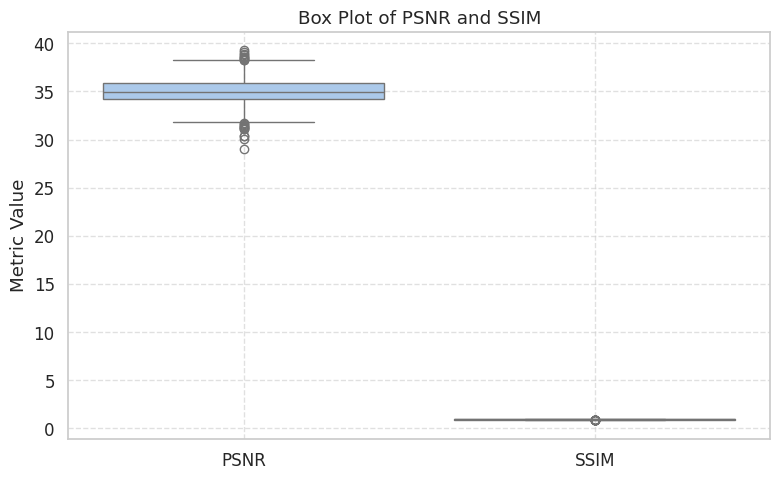

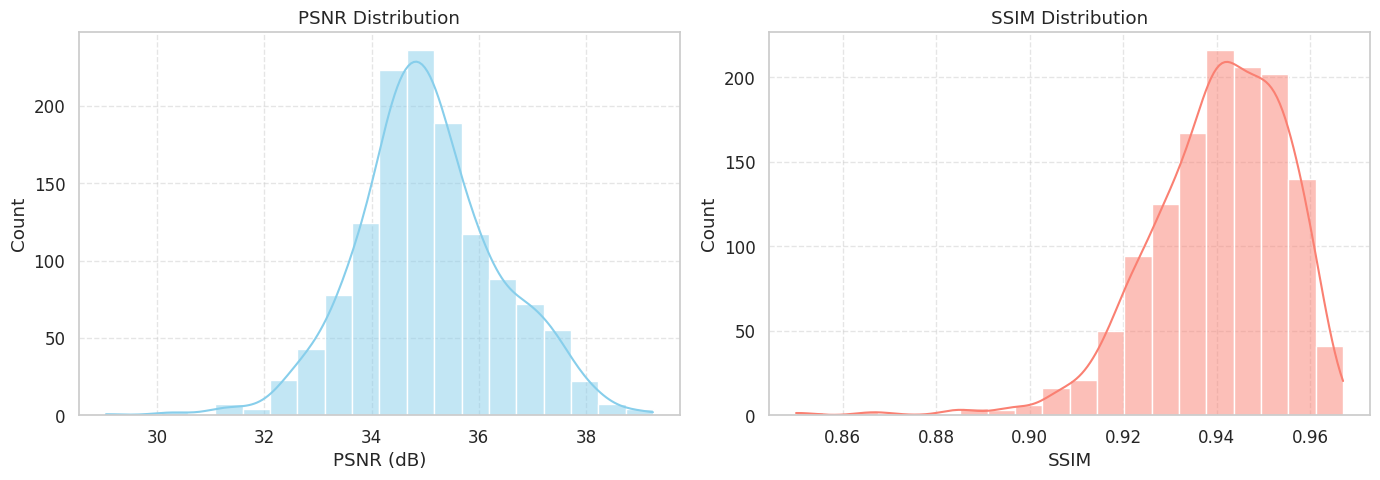

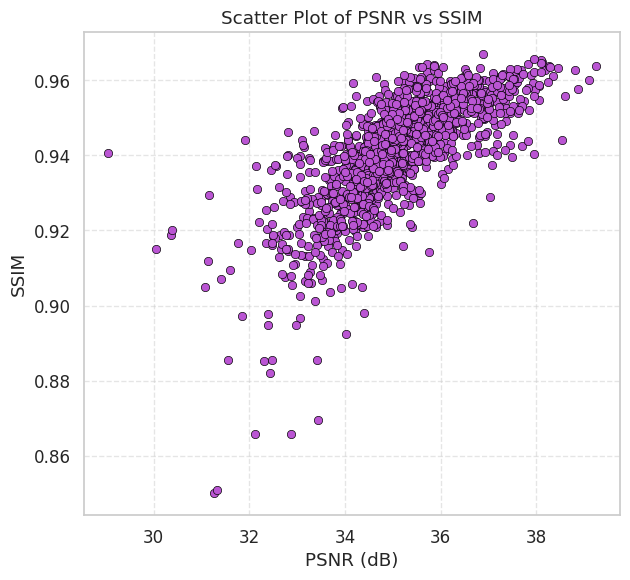


📊 Summary Statistics:


,PSNR,SSIM
mean,35.049329,0.940272
median,34.976102,0.941743
std,1.328454,0.014699


In [ ]:
# ===========================
#  Cell 8: PSNR/SSIM Visualization and Statistical Summary
# ===========================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Create output directory for visualizations ---
CLINICAL_DIR = os.path.join(OUTPUT_DIR, "clinical_panels")
os.makedirs(CLINICAL_DIR, exist_ok=True)

# --- Load evaluation metrics ---
df = pd.read_csv(os.path.join(OUTPUT_DIR, "metrics_rician.csv"))

# Set Seaborn style
sns.set(style="whitegrid", font_scale=1.1)

# --- Boxplot for PSNR and SSIM ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[["PSNR", "SSIM"]], palette="pastel")
plt.title("Box Plot of PSNR and SSIM")
plt.ylabel("Metric Value")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(CLINICAL_DIR, "boxplot_psnr_ssim.png"))
plt.show()

# --- Histograms with KDE for PSNR and SSIM ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["PSNR"], bins=20, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title("PSNR Distribution")
axes[0].set_xlabel("PSNR (dB)")
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.histplot(df["SSIM"], bins=20, kde=True, color='salmon', ax=axes[1])
axes[1].set_title("SSIM Distribution")
axes[1].set_xlabel("SSIM")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(CLINICAL_DIR, "histograms_psnr_ssim.png"))
plt.show()

# --- Scatter Plot: PSNR vs SSIM ---
plt.figure(figsize=(6.5, 6))
sns.scatterplot(x="PSNR", y="SSIM", data=df, color='mediumorchid', edgecolor='black')
plt.title("Scatter Plot of PSNR vs SSIM")
plt.xlabel("PSNR (dB)")
plt.ylabel("SSIM")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(CLINICAL_DIR, "scatter_psnr_vs_ssim.png"))
plt.show()

# --- Summary Statistics ---
summary_stats = df[["PSNR", "SSIM"]].agg(['mean', 'median', 'std'])
summary_stats.to_csv(os.path.join(CLINICAL_DIR, "summary_statistics.csv"))

# --- Display Summary Statistics Neatly ---
print("\n Summary Statistics:")
display(summary_stats.round(6))  # For Colab/Jupyter visual display


In [ ]:
  # ===========================
  #  Runtime Restore (Rician-Only Experiment)
  # ===========================

  import torch
  import pandas as pd
  import numpy as np
  import cv2
  import matplotlib.pyplot as plt
  from torch.utils.data import DataLoader, Dataset
  from torchvision import transforms
  from torchvision.utils import make_grid
  from skimage.metrics import peak_signal_noise_ratio as compute_psnr
  from skimage.metrics import structural_similarity as compute_ssim
  import os, glob

  # --- Reload Generator Definition ---
  class UNetGenerator(torch.nn.Module):
      def __init__(self, in_channels=1, out_channels=1, latent_dim=256):
          super().__init__()
          def conv_block(in_c, out_c, k=3, s=1, p=1):
              return torch.nn.Sequential(
                  torch.nn.Conv2d(in_c, out_c, k, s, p),
                  torch.nn.InstanceNorm2d(out_c),
                  torch.nn.LeakyReLU(0.2, inplace=True)
              )
          self.enc1 = conv_block(in_channels, 64)
          self.enc2 = conv_block(64, 128)
          self.enc3 = conv_block(128, 256)
          self.enc4 = conv_block(256, 512)
          self.pool = torch.nn.MaxPool2d(2)

          self.flatten = torch.nn.Flatten()
          self.fc_mu = torch.nn.Linear(512 * 16 * 16, latent_dim)
          self.fc_logvar = torch.nn.Linear(512 * 16 * 16, latent_dim)
          self.fc_decoder = torch.nn.Linear(latent_dim, 512 * 16 * 16)
          self.unflatten = torch.nn.Unflatten(1, (512, 16, 16))

          self.up1 = torch.nn.ConvTranspose2d(512, 256, 2, 2)
          self.dec1 = conv_block(512, 256)
          self.up2 = torch.nn.ConvTranspose2d(256, 128, 2, 2)
          self.dec2 = conv_block(256, 128)
          self.up3 = torch.nn.ConvTranspose2d(128, 64, 2, 2)
          self.dec3 = conv_block(128, 64)
          self.out_conv = torch.nn.Conv2d(64, out_channels, 1)

      def reparameterize(self, mu, logvar):
          std = torch.exp(0.5 * logvar)
          eps = torch.randn_like(std)
          return mu + eps * std

      def forward(self, x):
          e1 = self.enc1(x)
          e2 = self.enc2(self.pool(e1))
          e3 = self.enc3(self.pool(e2))
          e4 = self.enc4(self.pool(e3))
          e4_pool = self.pool(e4)

          flat = self.flatten(e4_pool)
          mu = self.fc_mu(flat)
          logvar = self.fc_logvar(flat)
          z = self.reparameterize(mu, logvar)
          z = self.unflatten(self.fc_decoder(z))
          z = torch.nn.functional.interpolate(z, size=(32, 32), mode='bilinear', align_corners=False)

          d1 = self.up1(z)
          d1 = self.dec1(torch.cat([d1, e3], dim=1))
          d2 = self.up2(d1)
          d2 = self.dec2(torch.cat([d2, e2], dim=1))
          d3 = self.up3(d2)
          d3 = self.dec3(torch.cat([d3, e1], dim=1))
          return torch.sigmoid(self.out_conv(d3)), mu, logvar

  # --- Reload Best Generator Weights (Rician checkpoint path) ---
  SAVE_PATH = "/content/drive/MyDrive/Final RI/checkpoints/rician"
  best_model_path = max(glob.glob(os.path.join(SAVE_PATH, "best_generator_epoch*.pt")), key=os.path.getctime)
  G = UNetGenerator().cuda()
  G.load_state_dict(torch.load(best_model_path))
  G.eval()
  print(f" Loaded best generator: {os.path.basename(best_model_path)}")

  # --- Redefine Dataset Class ---
  class MRIDenoisingDataset(Dataset):
      def __init__(self, noisy_dir, clean_dir, transform=None):
          noisy_all = sorted(glob.glob(os.path.join(noisy_dir, "*.*")))
          clean_all = sorted(glob.glob(os.path.join(clean_dir, "*.*")))
          noisy_dict = {os.path.basename(p): p for p in noisy_all}
          clean_dict = {os.path.basename(p): p for p in clean_all}
          common = sorted(set(noisy_dict.keys()) & set(clean_dict.keys()))
          self.noisy = [noisy_dict[f] for f in common]
          self.clean = [clean_dict[f] for f in common]
          self.transform = transform

      def __len__(self): return len(self.noisy)

      def __getitem__(self, idx):
          noisy = cv2.imread(self.noisy[idx], cv2.IMREAD_GRAYSCALE)
          clean = cv2.imread(self.clean[idx], cv2.IMREAD_GRAYSCALE)
          noisy = cv2.resize(noisy, (256, 256)).astype(np.float32) / 255.0
          clean = cv2.resize(clean, (256, 256)).astype(np.float32) / 255.0
          if self.transform:
              noisy = self.transform(noisy)
              clean = self.transform(clean)
          return noisy, clean

  # --- Load val_loader again (Rician paths) ---
  transform = transforms.ToTensor()
  val_loader = DataLoader(
      MRIDenoisingDataset(
          "/content/drive/MyDrive/Final RI/single_noise_outputs/single_noise_outputs_rician",
          "/content/drive/MyDrive/Final RI/glioma",
          transform
      ),
      batch_size=1, shuffle=False
  )

  # --- Reload Top-10 SSIM indices from Rician metrics ---
  OUTPUT_DIR = "/content/drive/MyDrive/Final RI/results/rician"
  metrics_df = pd.read_csv(os.path.join(OUTPUT_DIR, "metrics_rician.csv"))
  selected_samples = metrics_df.sort_values("SSIM", ascending=False).head(10)["index"].tolist()
  print(" Selected Top 10 Samples (by SSIM):", selected_samples)


✅ Loaded best generator: best_generator_epoch30_ssim0.9403.pt
📊 Selected Top 10 Samples (by SSIM): [199, 894, 241, 203, 870, 277, 631, 479, 1244, 131]


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from IPython.display import Image, display

# Load metrics
metrics_df = pd.read_csv("/content/drive/MyDrive/Final RI/results/rician/metrics_rician.csv")

# Top 10 SSIM samples
top_indices = metrics_df.sort_values("SSIM", ascending=False).head(10)["index"].tolist()

# Set paths
denoised_dir = "/content/drive/MyDrive/Final RI/results/rician/denoised_images"
noisy_dir    = "/content/drive/MyDrive/Final RI/single_noise_outputs/single_noise_outputs_rician"
clean_dir    = "/content/drive/MyDrive/Final RI/glioma"
save_dir     = "/content/drive/MyDrive/Final RI/results/rician/visualization_panels"

# Create output folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Create single figure: 10 rows × 3 columns
fig, axes = plt.subplots(nrows=10, ncols=3, figsize=(12, 40))
fig.subplots_adjust(hspace=0.4)

for row_idx, sample_idx in enumerate(top_indices):
    # Align filenames
    base_name = sorted(os.listdir(noisy_dir))[sample_idx]
    noisy_path    = os.path.join(noisy_dir, base_name)
    clean_path    = os.path.join(clean_dir, base_name)
    denoised_path = os.path.join(denoised_dir, f"denoised_{sample_idx:03d}.png")

    # Read images
    noisy    = cv2.imread(noisy_path, cv2.IMREAD_GRAYSCALE)
    clean    = cv2.imread(clean_path, cv2.IMREAD_GRAYSCALE)
    denoised = cv2.imread(denoised_path, cv2.IMREAD_GRAYSCALE)

    # Resize and normalize
    noisy    = cv2.resize(noisy, (256, 256)) / 255.0
    clean    = cv2.resize(clean, (256, 256)) / 255.0
    denoised = cv2.resize(denoised, (256, 256)) / 255.0

    # Plot each in its column
    axes[row_idx, 0].imshow(noisy, cmap='gray')
    axes[row_idx, 0].set_title(f" Noisy\nIdx: {sample_idx}")
    axes[row_idx, 0].axis('off')

    axes[row_idx, 1].imshow(denoised, cmap='gray')
    axes[row_idx, 1].set_title(" Denoised")
    axes[row_idx, 1].axis('off')

    axes[row_idx, 2].imshow(clean, cmap='gray')
    axes[row_idx, 2].set_title(" Ground Truth")
    axes[row_idx, 2].axis('off')

    # Add SSIM and PSNR as text under row
    ssim = metrics_df.loc[sample_idx, "SSIM"]
    psnr = metrics_df.loc[sample_idx, "PSNR"]
    axes[row_idx, 1].text(0.5, -0.1, f"SSIM: {ssim:.4f} | PSNR: {psnr:.2f} dB",
                          fontsize=10, ha='center', va='top', transform=axes[row_idx, 1].transAxes)

# Save full grid as one image
final_path = os.path.join(save_dir, "top10_visualization.png")
plt.tight_layout()
plt.savefig(final_path)
plt.close()

#  Display the saved image in Colab
print(f" Saved full visualization: {final_path}")
display(Image(filename=final_path))


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from IPython.display import Image, display

# Load metrics
metrics_df = pd.read_csv("/content/drive/MyDrive/Final RI/results/rician/metrics_rician.csv")

# Top 10 SSIM samples
top_indices = metrics_df.sort_values("SSIM", ascending=False).head(10)["index"].tolist()

# Set paths
denoised_dir = "/content/drive/MyDrive/Final RI/results/rician/denoised_images"
noisy_dir    = "/content/drive/MyDrive/Final RI/single_noise_outputs/single_noise_outputs_rician"
clean_dir    = "/content/drive/MyDrive/Final RI/glioma"
save_dir     = "/content/drive/MyDrive/Final RI/results/rician/visualization_panels"

# Create output folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Sort filenames once for consistent indexing
noisy_files = sorted(os.listdir(noisy_dir))

# Create single figure: 10 rows × 3 columns
fig, axes = plt.subplots(nrows=10, ncols=3, figsize=(12, 40))
fig.subplots_adjust(hspace=0.4)

for row_idx, sample_idx in enumerate(top_indices):

    # Align filenames
    base_name = noisy_files[sample_idx]
    noisy_path    = os.path.join(noisy_dir, base_name)
    clean_path    = os.path.join(clean_dir, base_name)
    denoised_path = os.path.join(denoised_dir, f"denoised_{sample_idx:03d}.png")

    # Read images (grayscale for medical imaging)
    noisy    = cv2.imread(noisy_path, cv2.IMREAD_GRAYSCALE)
    clean    = cv2.imread(clean_path, cv2.IMREAD_GRAYSCALE)
    denoised = cv2.imread(denoised_path, cv2.IMREAD_GRAYSCALE)

    # Resize and normalize
    noisy    = cv2.resize(noisy, (256, 256)) / 255.0
    clean    = cv2.resize(clean, (256, 256)) / 255.0
    denoised = cv2.resize(denoised, (256, 256)) / 255.0

    # --------------------------------------------------
    # Column Order: Ground Truth → Noisy → Denoised
    # --------------------------------------------------

    # Column 1 — Ground Truth Image
    axes[row_idx, 0].imshow(clean, cmap='gray')
    axes[row_idx, 0].set_title("Ground Truth Image")
    axes[row_idx, 0].axis('off')

    # Column 2 — Noisy Image
    axes[row_idx, 1].imshow(noisy, cmap='gray')
    axes[row_idx, 1].set_title(f"Noisy Image (Index: {sample_idx})")
    axes[row_idx, 1].axis('off')

    # Column 3 — Denoised Image (Model Output)
    axes[row_idx, 2].imshow(denoised, cmap='gray')
    axes[row_idx, 2].set_title("Denoised Image (Model Output)")
    axes[row_idx, 2].axis('off')

    # Display SSIM and PSNR below center column
    ssim = metrics_df.loc[sample_idx, "SSIM"]
    psnr = metrics_df.loc[sample_idx, "PSNR"]

    axes[row_idx, 1].text(
        0.5,
        -0.12,
        f"SSIM: {ssim:.4f} | PSNR: {psnr:.2f} dB",
        fontsize=10,
        ha='center',
        va='top',
        transform=axes[row_idx, 1].transAxes
    )

# Save as NEW file
new_filename = "top10_visualization_GT_first_medical.png"
final_path = os.path.join(save_dir, new_filename)

plt.tight_layout()
plt.savefig(final_path, dpi=300, bbox_inches='tight')
plt.close()

# Display in Colab
print(f"Saved medical visualization: {final_path}")
display(Image(filename=final_path))

Output hidden; open in https://colab.research.google.com to view.